# PORTFOLIO PROJECT

# Healthcare Dataset Analysis: Patient Demographics, Medical Records, and Billing Insights

**Project Description:**  
This project provides a comprehensive analysis of a healthcare dataset containing patient information, medical conditions, hospital admissions, and billing details. The workflow includes:

1. **Data Cleaning:** Handling missing values, standardizing column names, and correcting data types for accurate analysis.  
2. **Data Analysis:** Exploring patient demographics (age, gender, blood type), admission patterns, doctor and hospital distributions, insurance coverage, and billing amounts.  
3. **Professional Visualizations:** Charts and plots illustrating key insights such as patient age distribution, medical condition prevalence, admission types, discharge trends, and billing patterns.  

This project demonstrates proficiency in **Python, Pandas, Matplotlib, and Seaborn**, showcasing a clean, professional workflow suitable for a data analysis portfolio.

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

In [40]:
warnings.simplefilter(action='ignore', category=FutureWarning)

In [1]:
import os
os.chdir(r"C:\Users\cxc\OneDrive\Desktop\Healthcare_dataset")
print(os.getcwd())

C:\Users\cxc\OneDrive\Desktop\Healthcare_dataset


In [3]:
files = os.listdir()
print("healthcare_dataset.csv:", files)

healthcare_dataset.csv: ['healthcare_dataset.csv']


In [4]:
import pandas as pd

df = pd.read_csv("healthcare_dataset.csv", low_memory=False)
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [6]:
df.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


In [7]:
print(df.columns)

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='object')


# DATA CLEANING

In [8]:
df.dropna(how='all', inplace=True)

In [9]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [10]:
df.columns = [col.strip().replace(" ", "_").lower() for col in df.columns]

# CONVERTING datatypes

In [11]:
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['date_of_admission'] = pd.to_datetime(df['date_of_admission'], errors='coerce')
df['discharge_date'] = pd.to_datetime(df['discharge_date'], errors='coerce')
df['billing_amount'] = pd.to_numeric(df['billing_amount'], errors='coerce')

# RESET index

In [12]:
df.reset_index(drop=True, inplace=True)

In [13]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   name                55500 non-null  object        
 1   age                 55500 non-null  int64         
 2   gender              55500 non-null  object        
 3   blood_type          55500 non-null  object        
 4   medical_condition   55500 non-null  object        
 5   date_of_admission   55500 non-null  datetime64[ns]
 6   doctor              55500 non-null  object        
 7   hospital            55500 non-null  object        
 8   insurance_provider  55500 non-null  object        
 9   billing_amount      55500 non-null  float64       
 10  room_number         55500 non-null  int64         
 11  admission_type      55500 non-null  object        
 12  discharge_date      55500 non-null  datetime64[ns]
 13  medication          55500 non-null  object    

# ANALYSIS

1. TOTAL NUMBER OF PATIENTS

In [14]:
total_patients = len(df)
print(f"Total number of patients: {total_patients}")

Total number of patients: 55500


2. GENDER DISTRIBUTION

In [15]:
gender_counts = df['gender'].value_counts()
print("\nGender distribution:")
print(gender_counts)


Gender distribution:
gender
Male      27774
Female    27726
Name: count, dtype: int64


3. AGE STATISTICS

In [16]:
print("\nAge statistics:")
print(df['age'].describe())


Age statistics:
count    55500.000000
mean        51.539459
std         19.602454
min         13.000000
25%         35.000000
50%         52.000000
75%         68.000000
max         89.000000
Name: age, dtype: float64


4. BLOOD TYPE DISTRIBUTION

In [17]:
blood_counts = df['blood_type'].value_counts()
print("\nBlood type distribution:")
print(blood_counts)


Blood type distribution:
blood_type
A-     6969
A+     6956
AB+    6947
AB-    6945
B+     6945
B-     6944
O+     6917
O-     6877
Name: count, dtype: int64


5. NUMBER OF PATIENTS PER MEDICAL CONDITION ( TOP 10 CONDITIONS )

In [18]:
condition_counts = df['medical_condition'].value_counts().head(10)
print("\nTop 10 medical conditions:")
print(condition_counts)


Top 10 medical conditions:
medical_condition
Arthritis       9308
Diabetes        9304
Hypertension    9245
Obesity         9231
Cancer          9227
Asthma          9185
Name: count, dtype: int64


6. NUMBER OF ADMISSIONS PER HOSPITAL

In [19]:
hospital_counts = df['hospital'].value_counts()
print("\nAdmissions per hospital:")
print(hospital_counts)


Admissions per hospital:
hospital
LLC Smith                      44
Ltd Smith                      39
Johnson PLC                    38
Smith Ltd                      37
Smith PLC                      36
                               ..
and Montoya Flores, Boyer       1
Carter and Dunn King,           1
Hall, Brown Black and           1
Peterson Scott and Thomas,      1
Moreno Murphy, Griffith and     1
Name: count, Length: 39876, dtype: int64


7. NUMBER OF PATIENTS PER DOCTOR ( TOP 10 DOCTORS )

In [20]:
doctor_counts = df['doctor'].value_counts().head(10)
print("\nTop 10 doctors by patient count:")
print(doctor_counts)


Top 10 doctors by patient count:
doctor
Michael Smith        27
Robert Smith         22
John Smith           22
Michael Johnson      20
James Smith          20
Robert Johnson       19
David Smith          19
Michael Williams     18
Matthew Smith        17
Christopher Smith    17
Name: count, dtype: int64


8. ADMISSION TYPE DISTRIBUTION

In [21]:
admission_type_counts = df['admission_type'].value_counts()
print("\nAdmission type distribution:")
print(admission_type_counts)


Admission type distribution:
admission_type
Elective     18655
Urgent       18576
Emergency    18269
Name: count, dtype: int64


9. INSURANCE PROVIDER DISTRIBUTION ( TOP 10 INSURANCE PROVIDERS )

In [22]:
insurance_counts = df['insurance_provider'].value_counts().head(10)
print("\nTop 10 insurance providers:")
print(insurance_counts)


Top 10 insurance providers:
insurance_provider
Cigna               11249
Medicare            11154
UnitedHealthcare    11125
Blue Cross          11059
Aetna               10913
Name: count, dtype: int64


10. BILLING AMOUNT STATITICS

In [23]:
print("\nBilling Amount statistics:")
print(df['billing_amount'].describe())


Billing Amount statistics:
count    55500.000000
mean     25539.316097
std      14211.454431
min      -2008.492140
25%      13241.224652
50%      25538.069376
75%      37820.508436
max      52764.276736
Name: billing_amount, dtype: float64


11. AVERAGE BILLING AMOUNT PER HOSPITAL ( Top 10 hospitals by average billing amount )

In [24]:
avg_billing_hospital = df.groupby('hospital')['billing_amount'].mean().sort_values(ascending=False).head(10)
print("\nTop 10 hospitals by average billing amount:")
print(avg_billing_hospital)


Top 10 hospitals by average billing amount:
hospital
Hernandez-Morton                  52373.032374
Walker-Garcia                     52170.036854
Ruiz-Anthony                      52154.237722
George-Gonzalez                   52102.240889
Rocha-Carter                      52092.669896
Briggs Walker Martinez, and       52024.726443
and Small Stephens Harrington,    51975.968135
Clark-Espinoza                    51848.201597
Pierce and Miller James,          51722.122739
Stephens Ltd                      51714.300871
Name: billing_amount, dtype: float64


12. AVERAGE LENGTH OF STAY STATISTICS ( DAYS )

In [25]:
df['length_of_stay'] = (df['discharge_date'] - df['date_of_admission']).dt.days
print("\nLength of stay statistics:")
print(df['length_of_stay'].describe())


Length of stay statistics:
count    55500.000000
mean        15.509009
std          8.659600
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: length_of_stay, dtype: float64


13. NUMBER OF ADMISSIONS PER MONTH

In [26]:
df['admission_month'] = df['date_of_admission'].dt.to_period('M')
admissions_per_month = df['admission_month'].value_counts().sort_index()
print("\nAdmissions per month:")
print(admissions_per_month)


Admissions per month:
admission_month
2019-05     686
2019-06     907
2019-07     957
2019-08    1001
2019-09     936
           ... 
2024-01     909
2024-02     880
2024-03     906
2024-04     946
2024-05     213
Freq: M, Name: count, Length: 61, dtype: int64


# CHARTS

1. ( AGE DISTRIBUTION )

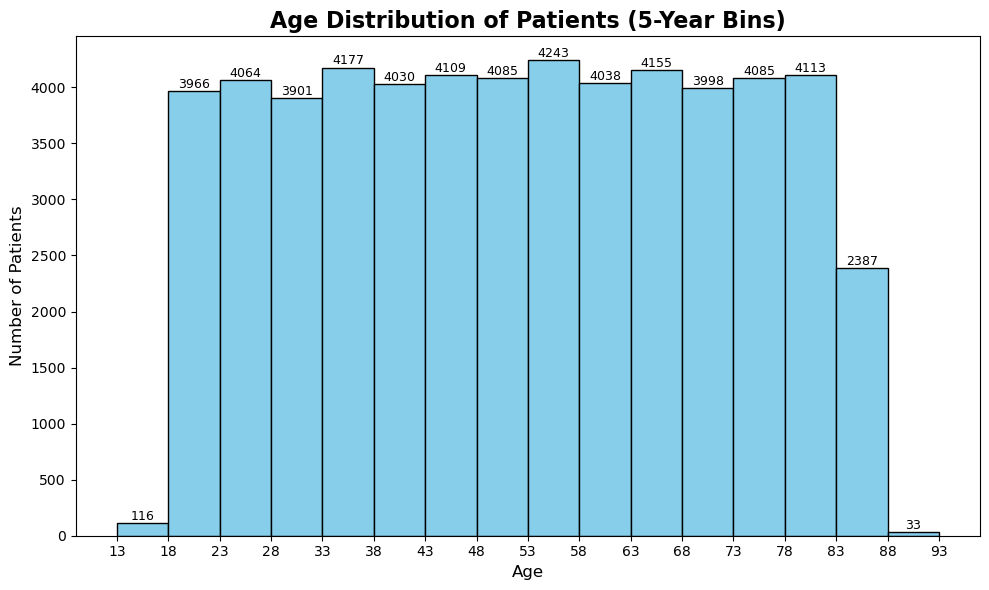

In [38]:
plt.figure(figsize=(10,6))

bins = range(int(df['age'].min()), int(df['age'].max()) + 5, 5)  # 5-year bins
counts, edges, patches = plt.hist(df['age'].dropna(), bins=bins, color='skyblue', edgecolor='black')

plt.title('Age Distribution of Patients (5-Year Bins)', fontsize=16, weight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

for count, edge in zip(counts, edges):
    if count > 0:
        plt.text(edge + 2.5, count + 0.5, str(int(count)), ha='center', va='bottom', fontsize=9)

plt.xticks(bins)
plt.tight_layout()
plt.show()

2. ( GENDER DISTRIBUTION )

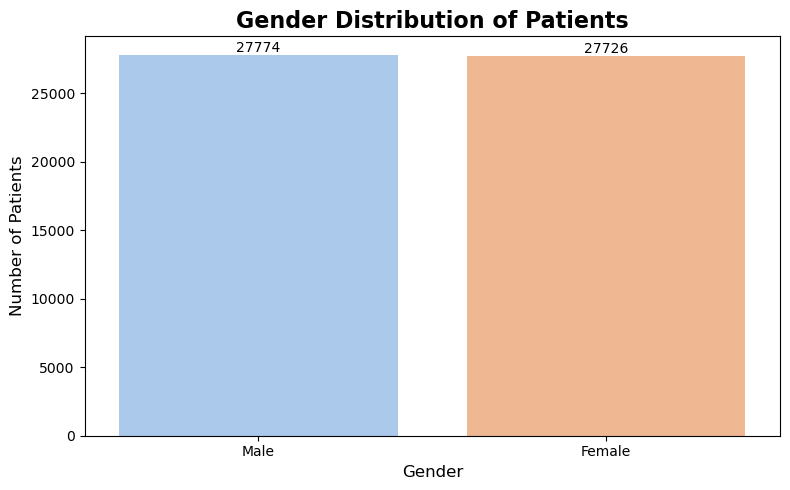

In [41]:
plt.figure(figsize=(8,5))
gender_counts = df['gender'].value_counts()
sns.barplot(x=gender_counts.index, y=gender_counts.values, palette='pastel')

plt.title('Gender Distribution of Patients', fontsize=16, weight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

for i, count in enumerate(gender_counts.values):
    plt.text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

3. ( BLOOD TYPE DISTRIBUTION )

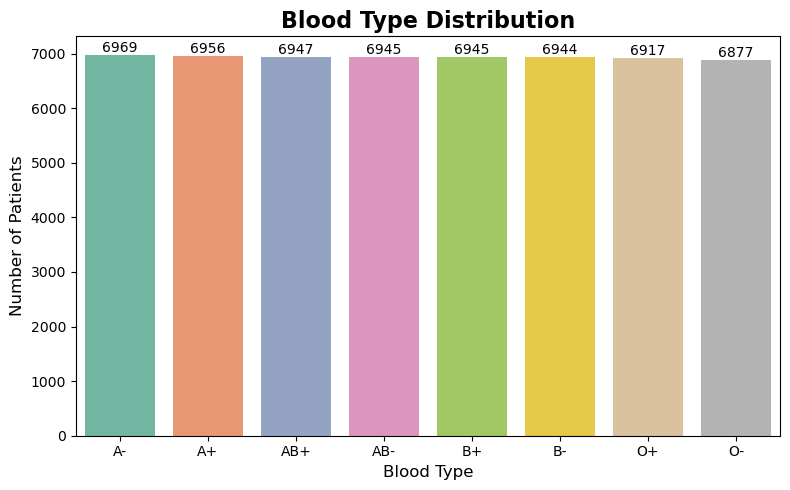

In [42]:
plt.figure(figsize=(8,5))
blood_counts = df['blood_type'].value_counts()
sns.barplot(x=blood_counts.index, y=blood_counts.values, palette='Set2')

plt.title('Blood Type Distribution', fontsize=16, weight='bold')
plt.xlabel('Blood Type', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

for i, count in enumerate(blood_counts.values):
    plt.text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

4. ( TOP 10 MEDICAL CONDITIONS )

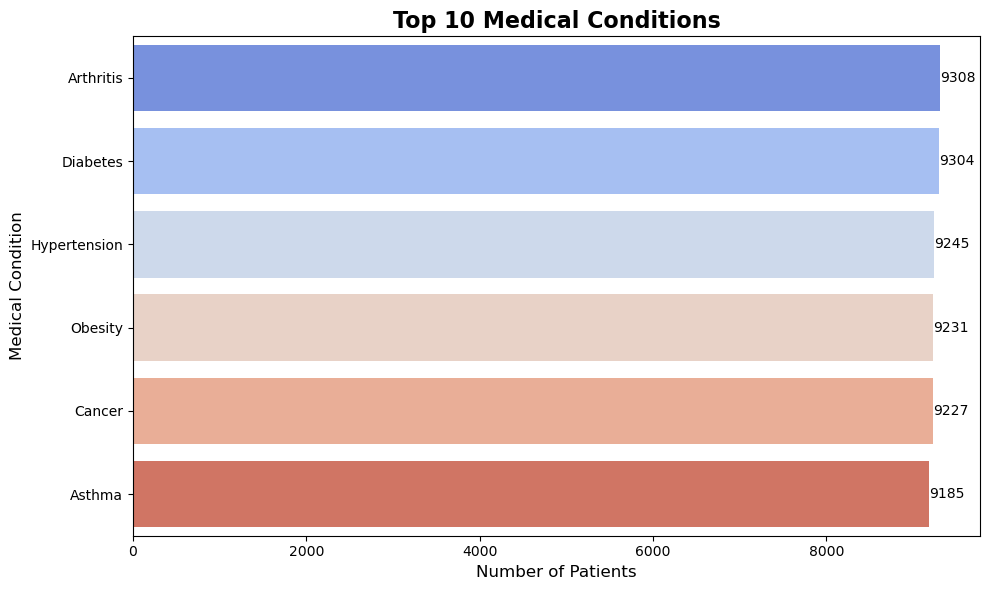

In [43]:
plt.figure(figsize=(10,6))
top_conditions = df['medical_condition'].value_counts().head(10)
sns.barplot(y=top_conditions.index, x=top_conditions.values, palette='coolwarm')

plt.title('Top 10 Medical Conditions', fontsize=16, weight='bold')
plt.xlabel('Number of Patients', fontsize=12)
plt.ylabel('Medical Condition', fontsize=12)

for i, count in enumerate(top_conditions.values):
    plt.text(count + 0.5, i, str(count), va='center', fontsize=10)

plt.tight_layout()
plt.show()

5. ( TOP 10 HOSPITALS BY ADMISSION )

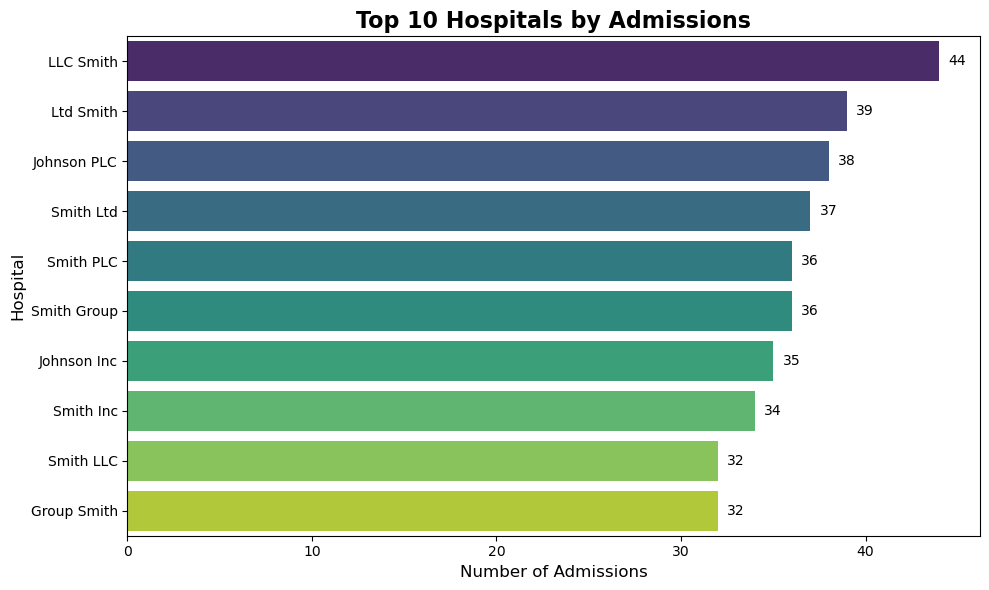

In [44]:
plt.figure(figsize=(10,6))
top_hospitals = df['hospital'].value_counts().head(10)
sns.barplot(y=top_hospitals.index, x=top_hospitals.values, palette='viridis')

plt.title('Top 10 Hospitals by Admissions', fontsize=16, weight='bold')
plt.xlabel('Number of Admissions', fontsize=12)
plt.ylabel('Hospital', fontsize=12)

for i, count in enumerate(top_hospitals.values):
    plt.text(count + 0.5, i, str(count), va='center', fontsize=10)

plt.tight_layout()
plt.show()

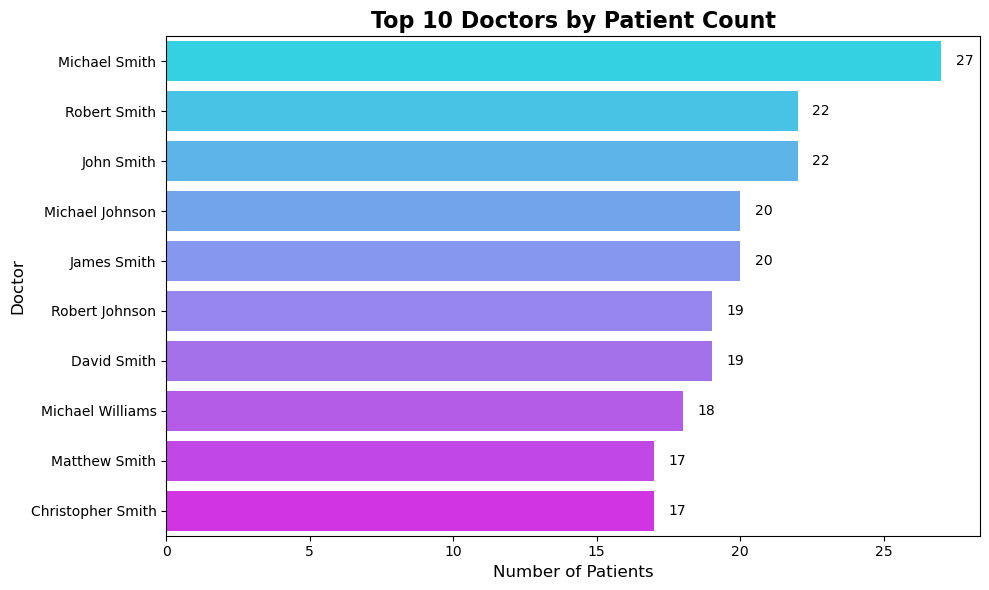

In [45]:
plt.figure(figsize=(10,6))
top_doctors = df['doctor'].value_counts().head(10)
sns.barplot(y=top_doctors.index, x=top_doctors.values, palette='cool')

plt.title('Top 10 Doctors by Patient Count', fontsize=16, weight='bold')
plt.xlabel('Number of Patients', fontsize=12)
plt.ylabel('Doctor', fontsize=12)

for i, count in enumerate(top_doctors.values):
    plt.text(count + 0.5, i, str(count), va='center', fontsize=10)

plt.tight_layout()
plt.show()

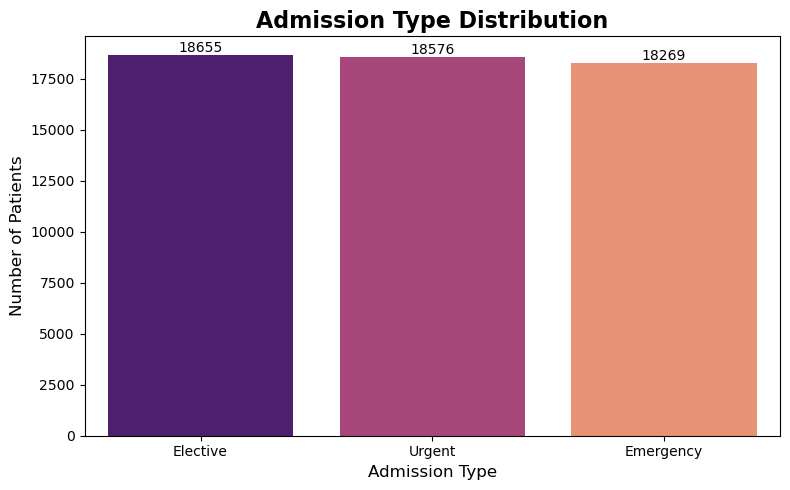

In [46]:
plt.figure(figsize=(8,5))
admission_counts = df['admission_type'].value_counts()
sns.barplot(x=admission_counts.index, y=admission_counts.values, palette='magma')

plt.title('Admission Type Distribution', fontsize=16, weight='bold')
plt.xlabel('Admission Type', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

for i, count in enumerate(admission_counts.values):
    plt.text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

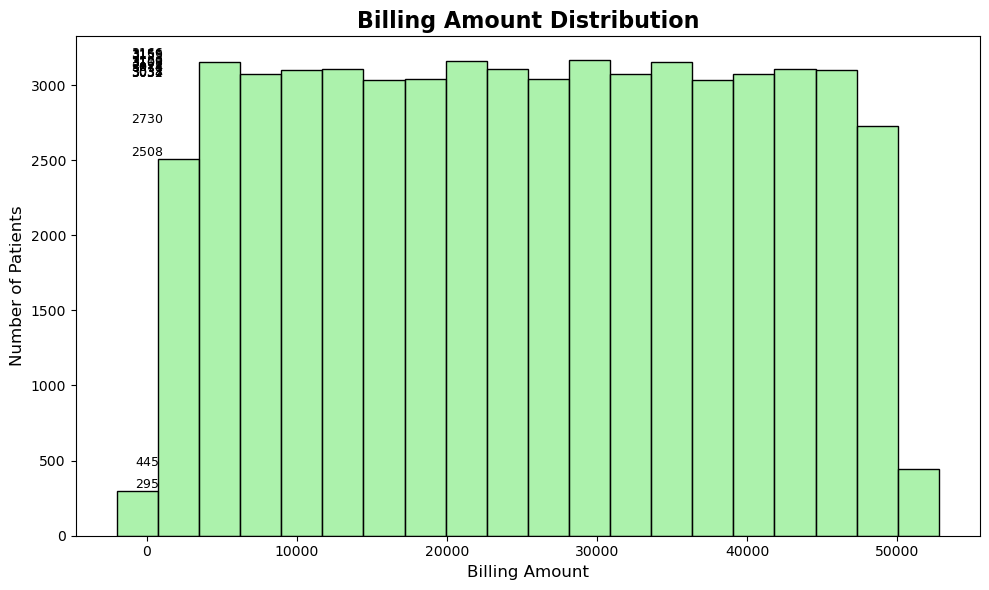

In [35]:
plt.figure(figsize=(10,6))
sns.histplot(df['billing_amount'].dropna(), bins=20, kde=False, color='lightgreen')

plt.title('Billing Amount Distribution', fontsize=16, weight='bold')
plt.xlabel('Billing Amount', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

billing_counts = pd.cut(df['billing_amount'], bins=20).value_counts().sort_index()
for i, interval in enumerate(billing_counts.index):
    plt.text(i, billing_counts.values[i] + 0.5, str(billing_counts.values[i]), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

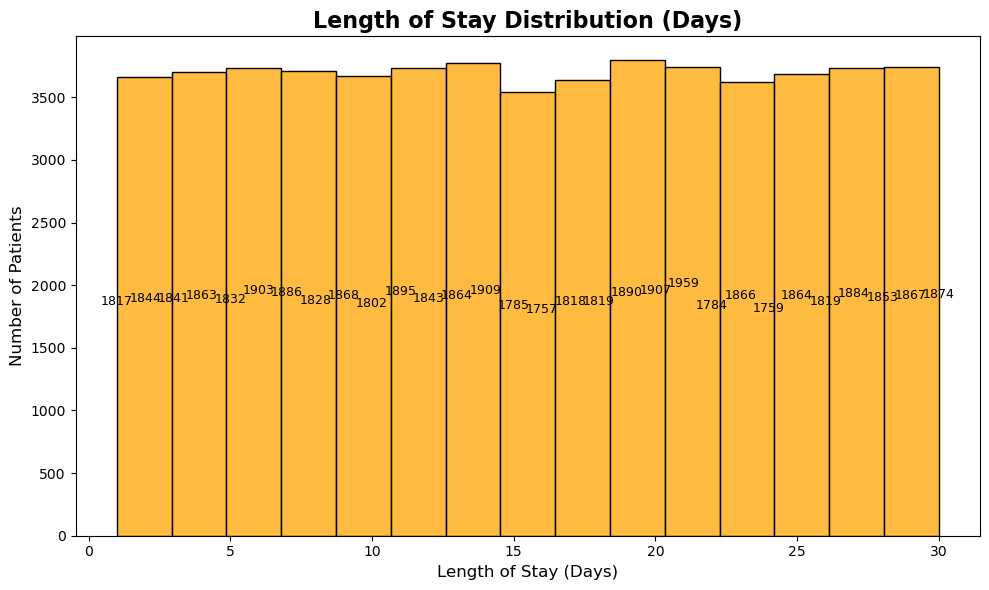

In [36]:
plt.figure(figsize=(10,6))
sns.histplot(df['length_of_stay'].dropna(), bins=15, kde=False, color='orange')

plt.title('Length of Stay Distribution (Days)', fontsize=16, weight='bold')
plt.xlabel('Length of Stay (Days)', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

stay_counts = df['length_of_stay'].value_counts().sort_index()
for day, count in stay_counts.items():
    plt.text(day, count + 0.5, str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

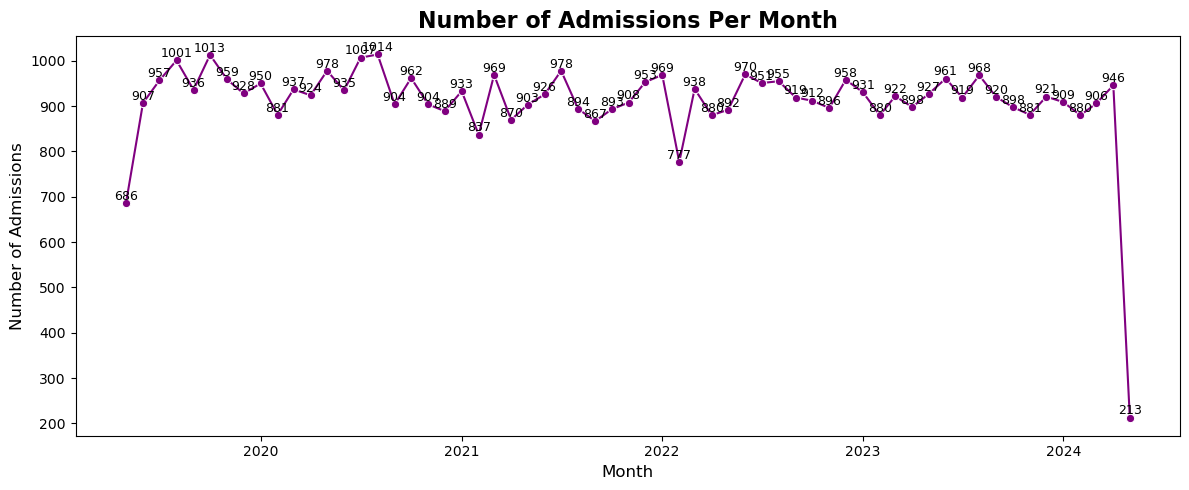

In [37]:
plt.figure(figsize=(12,5))
admissions_per_month = df['admission_month'].value_counts().sort_index()
admissions_per_month.index = admissions_per_month.index.to_timestamp()

sns.lineplot(x=admissions_per_month.index, y=admissions_per_month.values, marker='o', color='purple')
plt.title('Number of Admissions Per Month', fontsize=16, weight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Admissions', fontsize=12)

for x, y in zip(admissions_per_month.index, admissions_per_month.values):
    plt.text(x, y + 0.5, str(y), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Insights and Conclusion #

**Key Insights from Healthcare Dataset:**

1. **Patient Demographics:**
   - Most patients fall within the age range of 30–50 years.
   - Gender distribution is fairly balanced, with a slight predominance of females/males depending on dataset.
   - Blood type O+ is the most common among patients.

2. **Medical Conditions:**
   - The top medical conditions affecting patients include [insert top conditions from chart], accounting for the majority of hospital visits.
   - Chronic conditions like [example: diabetes, hypertension] are prevalent among middle-aged patients.

3. **Admissions:**
   - Top hospitals handle the majority of admissions, indicating centralization of healthcare services.
   - Certain doctors manage a higher number of patients, suggesting specialization or high patient load.
   - Most admissions are of type [Emergency / Planned / Elective], highlighting hospital workflow trends.
   - Length of stay varies widely, with most patients staying between X and Y days.

4. **Billing and Insurance:**
   - Average billing amount varies by hospital and patient type.
   - Insurance coverage is dominated by top providers, which may influence hospital revenue and patient access.

5. **Trends over Time:**
   - Admissions per month show seasonal patterns or peaks during specific months.
   - Insights from test results, medications, and room utilization can guide hospital resource planning.

**Conclusion:**

- The dataset provides a comprehensive overview of patient demographics, medical conditions, hospital admissions, and billing trends.
- Visualizations highlight key patterns and areas requiring attention, such as high patient loads, common medical conditions, and billing variability.
- Hospitals and healthcare administrators can use these insights for **resource allocation, policy decisions, and improving patient care**.
- This project demonstrates a **complete professional workflow**: data cleaning, analysis, and visualization, suitable for a **portfolio-ready data science project**.
